## Import Libraries & Read Dataset

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import scipy.cluster.hierarchy as sch
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv(r"C:\Users\shaha\Downloads\wine-clustering.csv")

In [3]:
data.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
data.shape

(178, 13)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


In [6]:
data.columns

Index(['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium',
       'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols',
       'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline'],
      dtype='object')

In [7]:
data.isnull().sum()

Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

In [8]:
df=data.copy()

In [9]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [10]:
sc_cols=['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium',
       'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols',
       'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline']

In [11]:
for i in sc_cols:
    data[i]=scaler.fit_transform(data[[i]])

In [12]:
data

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.876275,2.974543,0.305159,0.301803,-0.332922,-0.985614,-1.424900,1.274310,-0.930179,1.142811,-1.392758,-1.231206,-0.021952
174,0.493343,1.412609,0.414820,1.052516,0.158572,-0.793334,-1.284344,0.549108,-0.316950,0.969783,-1.129518,-1.485445,0.009893
175,0.332758,1.744744,-0.389355,0.151661,1.422412,-1.129824,-1.344582,0.549108,-0.422075,2.224236,-1.612125,-1.485445,0.280575
176,0.209232,0.227694,0.012732,0.151661,1.422412,-1.033684,-1.354622,1.354888,-0.229346,1.834923,-1.568252,-1.400699,0.296498


## K-Mean

In [13]:
from sklearn.cluster import KMeans

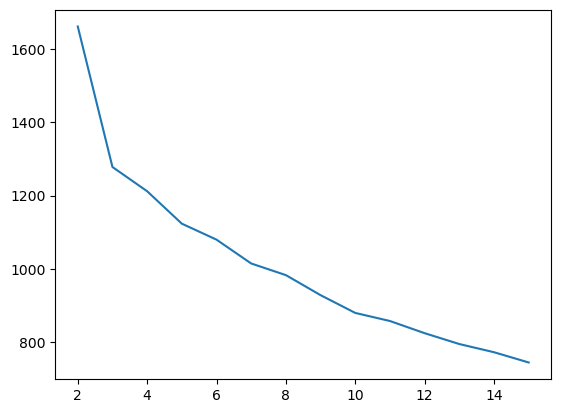

In [14]:
wcss=[]
for i in range(2,16):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(data)
    wcss.append(kmeans.inertia_)
plt.plot(range(2,16),wcss)
plt.show()

In [15]:
data=data.values

In [16]:
type(data)

numpy.ndarray

In [17]:
kmeans=KMeans(n_clusters=3,init='k-means++',random_state=42)
y_kmeans=kmeans.fit_predict(data)

In [18]:
y_kmeans

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)

In [19]:
kmeans_score=silhouette_score(data,y_kmeans)

In [20]:
print('Silhouette Score:',kmeans_score)

Silhouette Score: 0.2848589191898987


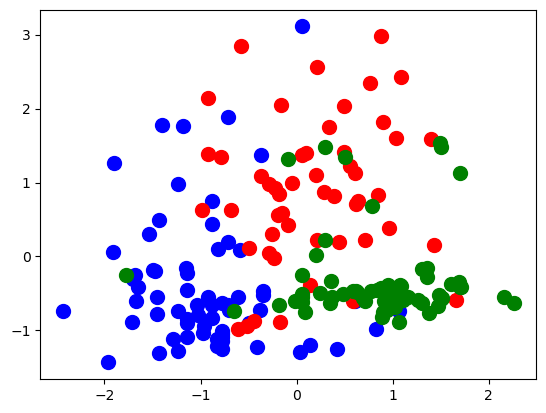

In [21]:
plt.scatter(data[y_kmeans==0,0],data[y_kmeans==0,1],s=100,c='blue',label='cluster1')
plt.scatter(data[y_kmeans==1,0],data[y_kmeans==1,1],s=100,c='red',label='cluster2')
plt.scatter(data[y_kmeans==2,0],data[y_kmeans==2,1],s=100,c='green',label='cluster3')
plt.show()

## Agglomerative

In [22]:
import scipy.cluster.hierarchy as sch

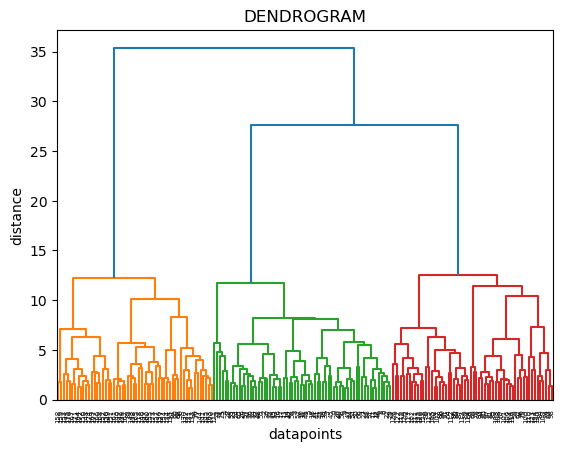

In [23]:
dendrogram=sch.dendrogram(sch.linkage(data,method="ward"))
plt.title("DENDROGRAM")
plt.xlabel("datapoints")
plt.ylabel("distance")
plt.show()

In [24]:
from sklearn.cluster import AgglomerativeClustering

In [25]:
agg=AgglomerativeClustering(n_clusters=3,metric='euclidean',linkage='ward')
y_agg=agg.fit_predict(data)

In [26]:
y_agg

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 1, 1, 0, 0, 0, 2,
       2, 0, 1, 0, 1, 2, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

In [27]:
agg_score=silhouette_score(data,y_agg)
agg_score

np.float64(0.2774439826952265)

## DBSCAN

In [28]:
pca=PCA(n_components=2)
x_pca=pca.fit_transform(data)

In [29]:
x_pca

array([[ 3.31675081,  1.44346263],
       [ 2.20946492, -0.33339289],
       [ 2.51674015,  1.0311513 ],
       [ 3.75706561,  2.75637191],
       [ 1.00890849,  0.86983082],
       [ 3.05025392,  2.12240111],
       [ 2.44908967,  1.17485013],
       [ 2.05943687,  1.60896307],
       [ 2.5108743 ,  0.91807096],
       [ 2.75362819,  0.78943767],
       [ 3.47973668,  1.30233324],
       [ 1.7547529 ,  0.61197723],
       [ 2.11346234,  0.67570634],
       [ 3.45815682,  1.13062988],
       [ 4.31278391,  2.09597558],
       [ 2.3051882 ,  1.66255173],
       [ 2.17195527,  2.32730534],
       [ 1.89897118,  1.63136888],
       [ 3.54198508,  2.51834367],
       [ 2.0845222 ,  1.06113799],
       [ 3.12440254,  0.78689711],
       [ 1.08657007,  0.24174355],
       [ 2.53522408, -0.09184062],
       [ 1.64498834, -0.51627893],
       [ 1.76157587, -0.31714893],
       [ 0.9900791 ,  0.94066734],
       [ 1.77527763,  0.68617513],
       [ 1.23542396, -0.08980704],
       [ 2.18840633,

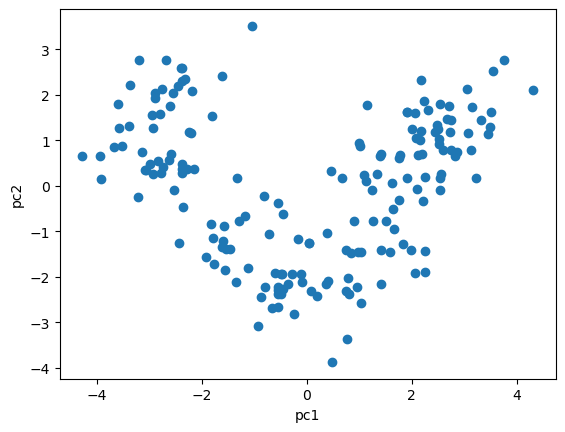

In [30]:
plt.scatter(x_pca[:,0],x_pca[:,1])
plt.xlabel("pc1")
plt.ylabel("pc2")
plt.show()

In [31]:
eps=0.7
min_poi=7
db=DBSCAN(eps=eps,min_samples=min_poi)

In [32]:
db_labels=db.fit_predict(x_pca)

In [33]:
db_labels

array([ 0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,
        0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  1,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,
        0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0, -1,  1,  1,  1,  0,  1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1])

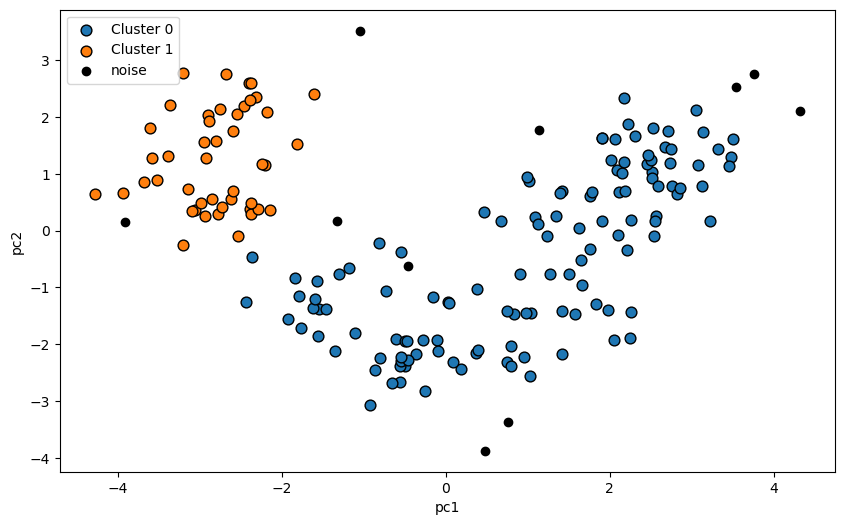

In [34]:
plt.figure(figsize=(10,6))
for label in set(db_labels):
    if label==-1:
        plt.scatter(x_pca[db_labels==label][:,0],x_pca[db_labels==label][:,1],c="black",label="noise"
    )
        
    else:
        plt.scatter(x_pca[db_labels==label][:,0],x_pca[db_labels==label][:,1],label=f'Cluster {label}' if label != -1 else 'Noise',
        edgecolors='k',
        s=60
    )
plt.xlabel("pc1")
plt.ylabel("pc2")
plt.legend()
plt.show()

In [35]:
db_score=silhouette_score(x_pca,db_labels)
db_score

np.float64(0.3506919025799976)

## GMM

In [36]:
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

In [37]:
x,y = make_blobs(
    n_samples=178,
    centers=3,
    random_state=42,
    cluster_std=[1.0, 1.5, 0.8]
)

In [38]:
gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    random_state=42
)

In [39]:
gmm.fit(x)

GaussianMixture(n_components=3, random_state=42)

In [40]:
labels = gmm.predict(x)

In [41]:
gmm_score = silhouette_score(x, labels)

In [42]:
print("Final Silhouette Score:", gmm_score)

Final Silhouette Score: 0.8249284285590218


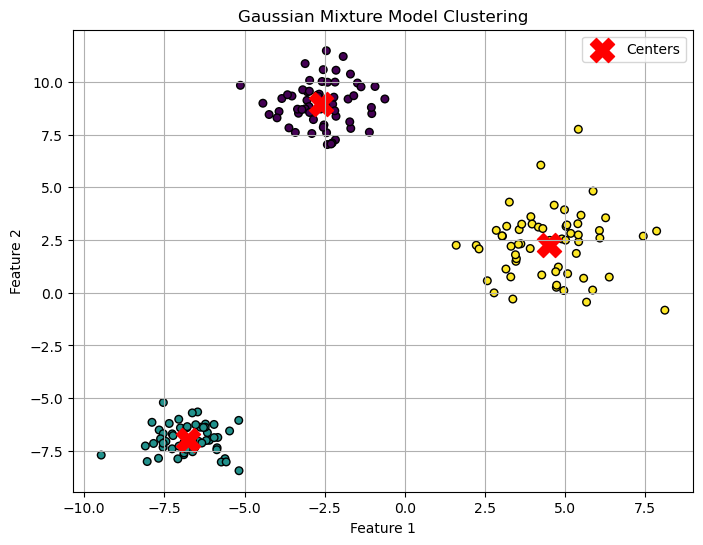

In [43]:
plt.figure(figsize=(8,6))
plt.scatter(x[:,0], x[:,1], c=labels, cmap='viridis', s=30, edgecolor='k')
plt.scatter(
    gmm.means_[:,0],
    gmm.means_[:,1],
    s=300,
    c='red',
    marker='X',
    label='Centers'
)

plt.title("Gaussian Mixture Model Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)

plt.show()

In [44]:
from tabulate import tabulate

In [45]:
table=[["METHOD","SILHOUETTE SCORE"],['K-MEANS',kmeans_score],
       ['AGGLOMERATIVE',agg_score],['DBSCAN',db_score],['GMM',gmm_score]]

In [46]:
print(tabulate(table,headers='firstrow',tablefmt='fancy_grid'))

╒═══════════════╤════════════════════╕
│ METHOD        │   SILHOUETTE SCORE │
╞═══════════════╪════════════════════╡
│ K-MEANS       │           0.284859 │
├───────────────┼────────────────────┤
│ AGGLOMERATIVE │           0.277444 │
├───────────────┼────────────────────┤
│ DBSCAN        │           0.350692 │
├───────────────┼────────────────────┤
│ GMM           │           0.824928 │
╘═══════════════╧════════════════════╛


In [47]:
labels

array([1, 2, 2, 1, 2, 1, 0, 2, 1, 1, 2, 0, 0, 2, 0, 1, 0, 1, 0, 0, 2, 2,
       2, 1, 1, 0, 0, 0, 1, 2, 0, 2, 1, 1, 0, 0, 2, 0, 2, 1, 1, 1, 1, 1,
       2, 0, 1, 1, 0, 1, 2, 2, 0, 2, 1, 0, 1, 0, 2, 1, 1, 2, 1, 2, 2, 1,
       0, 2, 1, 2, 2, 0, 2, 0, 0, 1, 2, 0, 2, 0, 0, 1, 2, 2, 0, 2, 2, 1,
       0, 2, 0, 0, 1, 1, 2, 2, 1, 0, 0, 0, 1, 2, 2, 1, 2, 1, 0, 0, 2, 2,
       2, 0, 2, 0, 1, 2, 2, 0, 2, 1, 0, 1, 2, 0, 2, 1, 2, 0, 1, 0, 1, 2,
       2, 1, 0, 0, 0, 2, 0, 0, 1, 2, 2, 1, 0, 1, 2, 0, 2, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 1, 2, 2, 1, 0, 2, 1, 0, 0, 1, 2, 1, 1, 0,
       1, 2])

In [48]:
df["cluster"]=labels

df["cluster"]=db_labels

In [49]:
len(labels)

178

In [50]:
df

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,cluster
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,2
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,1
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,1
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,0
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,1


In [51]:
set(labels)

{np.int64(0), np.int64(1), np.int64(2)}

set(db_labels)

In [52]:
cluster1=df.loc[df["cluster"]==0]

cluster1=df.loc[df["cluster"]==0]

In [53]:
cluster1

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,cluster
6,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290,0
11,14.12,1.48,2.32,16.8,95,2.20,2.43,0.26,1.57,5.00,1.17,2.82,1280,0
12,13.75,1.73,2.41,16.0,89,2.60,2.76,0.29,1.81,5.60,1.15,2.90,1320,0
14,14.38,1.87,2.38,12.0,102,3.30,3.64,0.29,2.96,7.50,1.20,3.00,1547,0
16,14.30,1.92,2.72,20.0,120,2.80,3.14,0.33,1.97,6.20,1.07,2.65,1280,0
18,14.19,1.59,2.48,16.5,108,3.30,3.93,0.32,1.86,8.70,1.23,2.82,1680,0
19,13.64,3.10,2.56,15.2,116,2.70,3.03,0.17,1.66,5.10,0.96,3.36,845,0
25,13.05,2.05,3.22,25.0,124,2.63,2.68,0.47,1.92,3.58,1.13,3.20,830,0
26,13.39,1.77,2.62,16.1,93,2.85,2.94,0.34,1.45,4.80,0.92,3.22,1195,0
27,13.30,1.72,2.14,17.0,94,2.40,2.19,0.27,1.35,3.95,1.02,2.77,1285,0


In [54]:
cluster1.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,cluster
count,60.000000,60.000000,60.00000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.0
mean,12.962667,2.454333,2.41300,20.055000,98.533333,2.337167,2.039833,0.373333,1.620333,5.303833,0.946167,2.557000,775.216667,0.0
std,0.812320,1.196692,0.24134,3.469403,12.755147,0.639823,1.003393,0.128850,0.508457,2.567252,0.228926,0.650203,337.852394,0.0
min,11.410000,0.740000,1.70000,12.000000,78.000000,1.250000,0.470000,0.130000,0.730000,2.000000,0.480000,1.270000,278.000000,0.0
25%,12.280000,1.665000,2.25750,18.000000,88.000000,1.735000,1.177500,0.290000,1.257500,3.240000,0.780000,1.950000,501.500000,0.0
50%,13.050000,1.945000,2.41500,20.000000,96.500000,2.410000,2.225000,0.325000,1.630000,5.050000,0.985000,2.750000,677.500000,0.0
75%,13.522500,3.192500,2.56500,22.000000,108.500000,2.835000,2.807500,0.472500,1.882500,6.450000,1.100000,3.105000,1065.000000,0.0
max,14.390000,5.800000,3.22000,30.000000,139.000000,3.880000,3.930000,0.630000,2.960000,13.000000,1.420000,3.580000,1680.000000,0.0


In [55]:
cluster2=df.loc[df["cluster"]==1]

In [56]:
cluster2.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,cluster
count,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.0
mean,13.148305,2.329492,2.364746,19.198305,102.067797,2.315085,2.026610,0.367966,1.506780,5.286610,0.934407,2.586949,749.338983,1.0
std,0.814049,1.073891,0.291520,3.324491,13.525027,0.626263,1.089086,0.128704,0.493881,2.295446,0.219390,0.785257,290.282301,0.0
min,11.560000,0.940000,1.360000,10.600000,80.000000,1.280000,0.470000,0.140000,0.410000,1.280000,0.560000,1.290000,290.000000,1.0
25%,12.395000,1.655000,2.255000,16.900000,89.500000,1.690000,1.040000,0.260000,1.200000,3.660000,0.780000,1.790000,520.000000,1.0
50%,13.340000,1.880000,2.360000,19.400000,101.000000,2.420000,2.170000,0.370000,1.540000,5.000000,0.930000,2.850000,680.000000,1.0
75%,13.750000,2.975000,2.570000,21.000000,112.000000,2.825000,2.940000,0.475000,1.885000,6.925000,1.105000,3.290000,987.500000,1.0
max,14.830000,5.650000,3.230000,28.500000,134.000000,3.850000,5.080000,0.660000,2.340000,11.750000,1.360000,3.920000,1480.000000,1.0


In [57]:
noise=df.loc[df["cluster"]==-1]

In [58]:
noise.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,cluster
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [59]:
df = pd.DataFrame(x, columns=["Feature1","Feature2"])
df["Cluster"] = labels

In [60]:
df.groupby("Cluster").mean()

,Feature1,Feature2
Cluster,,
0,-2.603061,8.959795
1,-6.755954,-6.966353
2,4.501890,2.282192
